# Ablation — Axe 3 : Stratégie de vérification

**Question :** Quel critère de vérification est le plus utile ?

- **CartPole** : `safety` | `stability` | `combined`
- **CliffWalking** : `safety` | `lookahead` | `combined` (notebook CliffWalking)

`RUN_TRAINING=True` entraîne CartPole config 1 avec les 3 stratégies.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
from ablation_utils import *


In [2]:
RUN_TRAINING = False
WM_CONFIG = 1  # fixer config WM pour isoler l'effet stratégie


In [3]:
results = {}

# CartPole — entraînement multi-stratégie
if RUN_TRAINING:
    for strat in ENV_SPECS["CartPole-v1"]["verif_strategies"]:
        results[f"cartpole_{strat}"] = run_multi_seed_cartpole(
            train_dqn_cartpole, use_precedence=True, wm_config=WM_CONFIG, verify_strategy=strat)
        print(f"CartPole {strat}: {results[f'cartpole_{strat}']['final_mean']:.1f}")
else:
    # Charge config 1 comme proxy (stratégie combined par défaut dans les JSON)
    e = load_precedence_config("dqn", "CartPole-v1", WM_CONFIG)
    if e:
        e["label"] = "combined (saved)"
        results["cartpole_combined_saved"] = e
    print("⚠ Pour safety/stability séparés: RUN_TRAINING=True ou entraîner manuellement")

# CliffWalking — charge résultats existants (combined dans JSON)
for cfg in [1, 2, 3]:
    e = load_precedence_config("dqn", "CliffWalking-v1", cfg)
    if e:
        results[f"cliff_config{cfg}"] = e


⚠ Pour safety/stability séparés: RUN_TRAINING=True ou entraîner manuellement


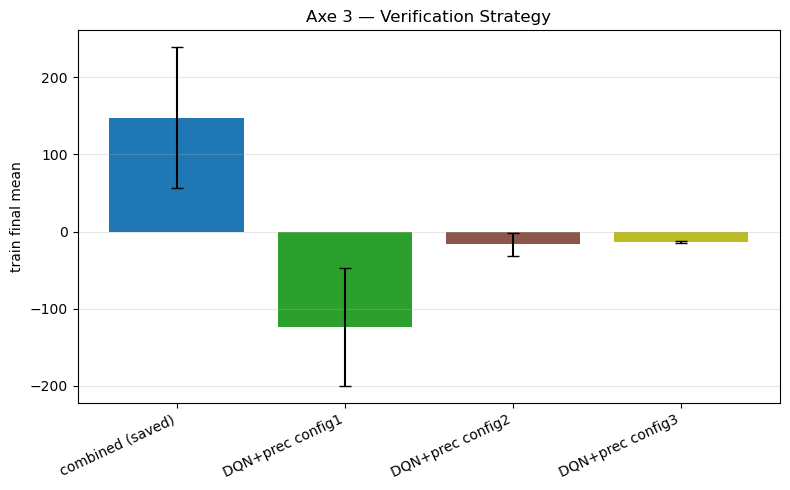

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_verif_strategy.png
✅ Saved → /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/results/ablation_verif_strategy.json


PosixPath('/Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/results/ablation_verif_strategy.json')

In [4]:
entries = []
for k, v in results.items():
    if isinstance(v, dict) and "final_mean" in v:
        entries.append({"label": k, "train_final_mean": v["final_mean"], "train_final_std": v["final_std"],
                        "eval_mean": v.get("eval_mean", 0), "rewards": v["reward_curves"][0] if v.get("reward_curves") else []})
    elif isinstance(v, dict) and "train_final_mean" in v:
        entries.append(v)

if entries:
    plot_bar_comparison(entries, "Axe 3 — Verification Strategy", "ablation_verif_strategy.png")

save_ablation_result("ablation_verif_strategy", results)
